In [1]:
import sys
from pathlib import Path
import twelvedata
from twelvedata import TDClient
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))
from config import TD_API_KEY

Python: /opt/anaconda3/bin/python
openai: 0.28.1
chapyter: 0.3.1


### Fetch current price

In [8]:
# Initialize client with your API key
td = TDClient(apikey=TD_API_KEY)

# Get latest price for Apple
price = td.price(symbol="EXN").as_json()

print(price)

{'price': '0.34000'}


### Calculate corelation between two stocks

In [4]:
# Initialize client with your API key
td = TDClient(apikey=TD_API_KEY)

# Fetch historical price data for Tesla
tsla_ts = td.time_series(
    symbol="EXN",
    interval="1day",
    outputsize=100
).as_pandas()

# Fetch historical price data for Microsoft
msft_ts = td.time_series(
    symbol="WRLG",
    interval="1day",
    outputsize=100
).as_pandas()

# Align data on datetime index
combined = pd.concat(
    [tsla_ts['close'].astype(float), msft_ts['close'].astype(float)],
    axis=1,
    keys=["EXN", "WRLG"]
).dropna()

# Calculate correlation
correlation = combined["EXN"].corr(combined["WRLG"])
print(f"Correlation of closing prices between EXN and WRLG: {correlation:.2f}")

Correlation of closing prices between TSLA and MSFT: 0.61


### Plot Time Series

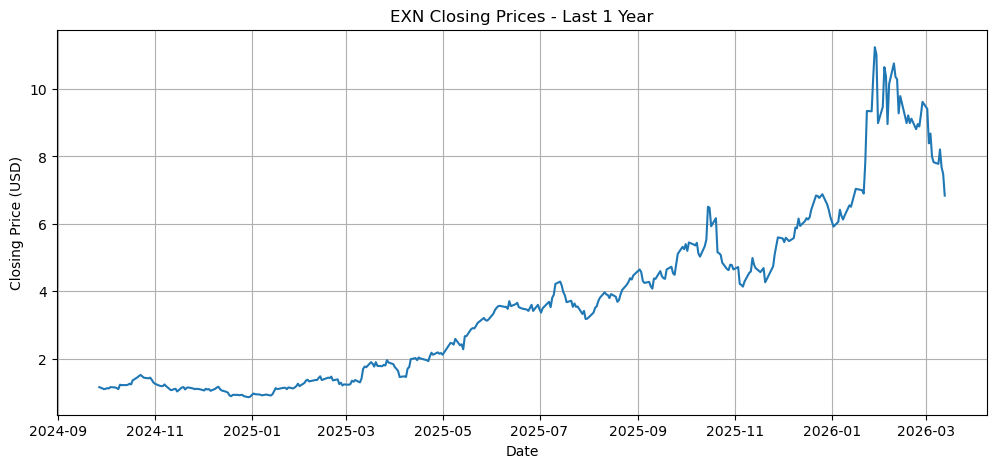

In [10]:
url = "https://api.twelvedata.com/time_series"

params = {
    "symbol": "ASM",
    "interval": "1day",
    "outputsize": 365,
    "apikey": TD_API_KEY
}

response = requests.get(url, params=params)
data = response.json()

# Handle errors
if "values" not in data:
    print("Error:", data)
    exit()

df = pd.DataFrame(data["values"])
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")
df["close"] = df["close"].astype(float)

plt.figure(figsize=(12, 5))
plt.plot(df["datetime"], df["close"])
plt.title("EXN Closing Prices - Last 1 Year")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)
plt.show()